6. Write a program to visualize machine learning model outputs, including confusion matrices, ROC curves, and feature importance plots.

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import RocCurveDisplay


In [62]:
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

In [63]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [64]:
model = RandomForestClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)


<Axes: >

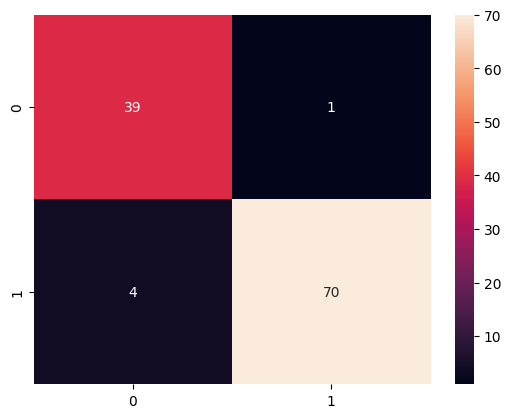

In [65]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True)

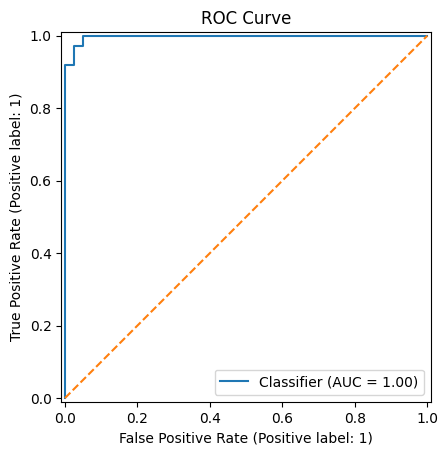

In [66]:
RocCurveDisplay.from_predictions(y_test, y_prob[:, 1])
plt.plot([0, 1], [0, 1], '--')
plt.title("ROC Curve")
plt.show()

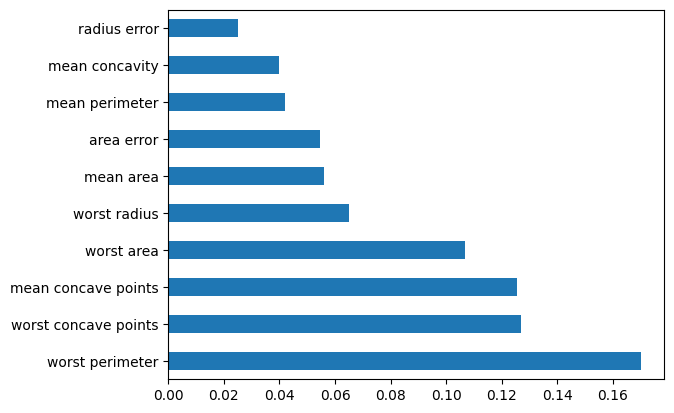

In [67]:
pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()
plt.show()